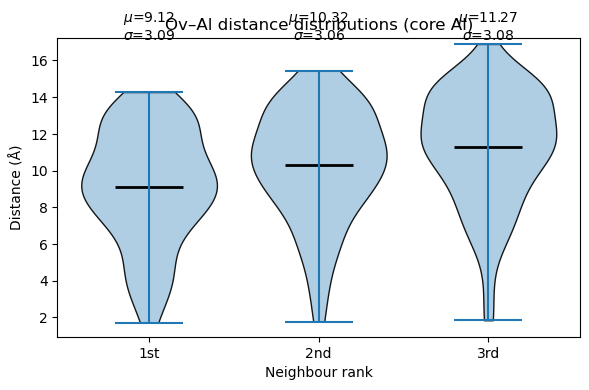

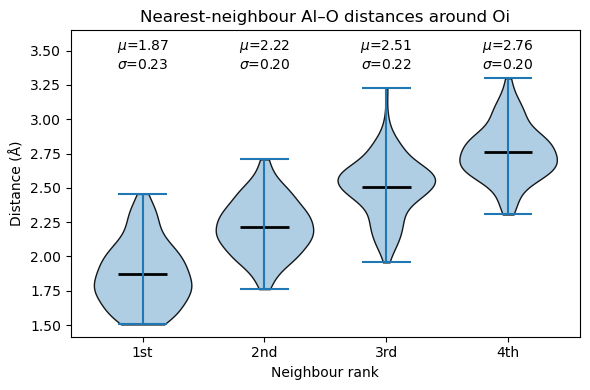

=== Ov–Al first-shell average distance ===
mean = 10.237 Å
std  = 3.048 Å


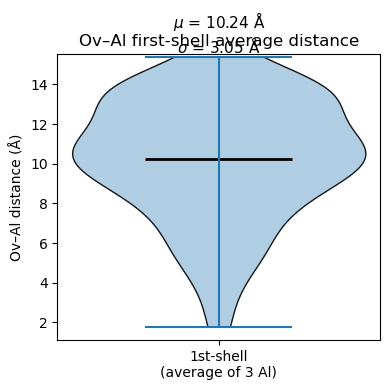

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# Settings
# ==================================================
SUMMARY_CSV = "OvOi_event_summary.csv"

TYPE_OV_AL  = 4          # Ov-core Al
TYPE_AL_ALL = [1, 4]     # all Al (bulk + core)

# ==================================================
# Utilities
# ==================================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)


def read_lammps_atoms(filename):
    with open(filename) as f:
        lines = f.readlines()

    # ---------- box ----------
    def find_bounds(axis):
        key = f"{axis}lo {axis}hi"
        for l in lines:
            if key in l:
                lo, hi = map(float, l.split()[:2])
                return lo, hi
        raise RuntimeError(f"[{filename}] box bounds not found for {axis}")

    xlo, xhi = find_bounds("x")
    ylo, yhi = find_bounds("y")
    zlo, zhi = find_bounds("z")
    box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

    # ---------- find Masses ----------
    masses_idx = None
    for i, l in enumerate(lines):
        if l.strip().startswith("Masses"):
            masses_idx = i
            break
    if masses_idx is None:
        raise RuntimeError(f"[{filename}] Masses section not found")

    # ---------- find first atom line ----------
    start = None
    for i in range(masses_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) >= 7:
            try:
                int(parts[0])
                int(parts[2])
                float(parts[4])
                float(parts[5])
                float(parts[6])
                start = i
                break
            except ValueError:
                continue

    if start is None:
        raise RuntimeError(f"[{filename}] atom block not found")

    # ---------- read atoms ----------
    pos, types = [], []
    for i in range(start, len(lines)):
        s = lines[i].strip()
        if not s:
            break
        parts = s.split()
        if len(parts) < 7:
            break
        try:
            int(parts[0])
            int(parts[2])
        except ValueError:
            break

        types.append(int(parts[2]))
        pos.append([float(parts[4]), float(parts[5]), float(parts[6])])

    return np.asarray(pos), np.asarray(types), box


# ==================================================
# Main analysis
# ==================================================
df = pd.read_csv(SUMMARY_CSV)

# Ov–Al: rank 1–3
ov_al = {1: [], 2: [], 3: []}

# Oi–Al: rank 1–4
oi_al = {1: [], 2: [], 3: [], 4: []}

for _, row in df.iterrows():
    eid = int(row["event_id"])
    datafile = f"event_{eid:03d}_OvOi.data"

    pos, types, box = read_lammps_atoms(datafile)

    Ov = np.array([row["Ov_x"], row["Ov_y"], row["Ov_z"]], dtype=float)
    Oi = np.array([row["Oi_x"], row["Oi_y"], row["Oi_z"]], dtype=float)

    # ---------- Ov → 3 core Al (ranked) ----------
    core_idx = np.where(types == TYPE_OV_AL)[0]
    if len(core_idx) != 3:
        raise RuntimeError(f"[event {eid:03d}] core Al count = {len(core_idx)}")

    core_pos = pos[core_idx]
    disp = minimum_image(core_pos - Ov, box)
    d_core = np.linalg.norm(disp, axis=1)

    order = np.argsort(d_core)
    for r, idx in enumerate(order, start=1):
        ov_al[r].append(d_core[idx])

    # ---------- Oi → 4 nearest Al ----------
    al_idx = np.where(np.isin(types, TYPE_AL_ALL))[0]
    al_pos = pos[al_idx]

    disp = minimum_image(al_pos - Oi, box)
    d_all = np.linalg.norm(disp, axis=1)

    order = np.argsort(d_all)[:4]
    for r, idx in enumerate(order, start=1):
        oi_al[r].append(d_all[idx])


# ==================================================
# Plot helper: violin + mean/std annotation
# ==================================================
def plot_violin_by_rank(data_dict, title, xlabel):
    ranks = sorted(data_dict.keys())
    data = [data_dict[r] for r in ranks]

    plt.figure(figsize=(6, 4))
    parts = plt.violinplot(
        data,
        showmeans=True,
        showextrema=True,
        widths=0.8
    )

    # style
    for pc in parts["bodies"]:
        pc.set_facecolor("#A6C8E0")
        pc.set_edgecolor("black")
        pc.set_alpha(0.9)

    parts["cmeans"].set_color("black")
    parts["cmeans"].set_linewidth(2)

    plt.xticks(range(1, len(ranks) + 1),
               [f"{r}st" if r == 1 else f"{r}nd" if r == 2 else f"{r}rd" if r == 3 else f"{r}th"
                for r in ranks])

    plt.ylabel("Distance (Å)")
    plt.xlabel(xlabel)
    plt.title(title)

    ymax = max(max(v) for v in data)

    for i, r in enumerate(ranks, start=1):
        arr = np.array(data_dict[r])
        mu = arr.mean()
        sigma = arr.std()
        plt.text(
            i,
            ymax + 0.05,
            f"$\\mu$={mu:.2f}\n$\\sigma$={sigma:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.ylim(top=ymax + 0.35)
    plt.tight_layout()
    plt.show()


# ==================================================
# Figures
# ==================================================
plot_violin_by_rank(
    ov_al,
    title="Ov–Al distance distributions (core Al)",
    xlabel="Neighbour rank"
)

plot_violin_by_rank(
    oi_al,
    title="Nearest-neighbour Al–O distances around Oi",
    xlabel="Neighbour rank"
)

# ==================================================
# Ov–Al first-shell average distance (per event)
# ==================================================
ov_al_avg = []

n_events = len(ov_al[1])
for i in range(n_events):
    avg_d = (
        ov_al[1][i] +
        ov_al[2][i] +
        ov_al[3][i]
    ) / 3.0
    ov_al_avg.append(avg_d)

ov_al_avg = np.array(ov_al_avg)

print("=== Ov–Al first-shell average distance ===")
print(f"mean = {ov_al_avg.mean():.3f} Å")
print(f"std  = {ov_al_avg.std():.3f} Å")


# ==================================================
# Plot: Ov–Al first-shell average (violin)
# ==================================================
plt.figure(figsize=(4, 4))

parts = plt.violinplot(
    ov_al_avg,
    showmeans=True,
    showextrema=True,
    widths=0.6
)

for pc in parts["bodies"]:
    pc.set_facecolor("#A6C8E0")
    pc.set_edgecolor("black")
    pc.set_alpha(0.9)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linewidth(2)

mu = ov_al_avg.mean()
sigma = ov_al_avg.std()

plt.xticks([1], ["1st-shell\n(average of 3 Al)"])
plt.ylabel("Ov–Al distance (Å)")
plt.title("Ov–Al first-shell average distance")

plt.text(
    1,
    ov_al_avg.max() + 0.03,
    f"$\\mu$ = {mu:.2f} Å\n$\\sigma$ = {sigma:.2f} Å",
    ha="center",
    va="bottom",
    fontsize=11
)

plt.ylim(top=ov_al_avg.max() + 0.15)
plt.tight_layout()
plt.show()

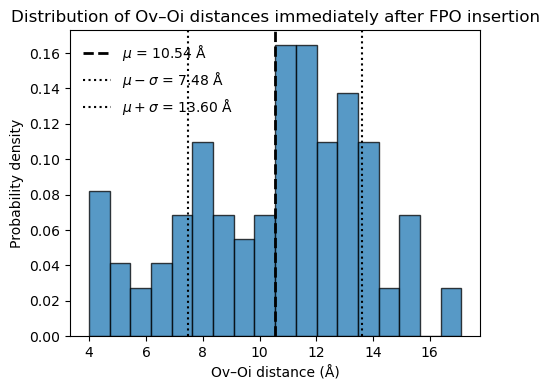

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# Settings
# =====================================
SUMMARY_CSV = "OvOi_event_summary.csv"
NBINS = 18

# =====================================
# Load data
# =====================================
df = pd.read_csv(SUMMARY_CSV)
d = df["Ov_Oi_dist"].values

mu = d.mean()
sigma = d.std()

# =====================================
# Plot
# =====================================
plt.figure(figsize=(5, 4))

# histogram
plt.hist(
    d,
    bins=NBINS,
    density=True,
    alpha=0.75,
    edgecolor="black"
)

# mean and std lines
plt.axvline(
    mu,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"$\\mu$ = {mu:.2f} Å"
)

plt.axvline(
    mu - sigma,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"$\\mu - \\sigma$ = {mu - sigma:.2f} Å"
)

plt.axvline(
    mu + sigma,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"$\\mu + \\sigma$ = {mu + sigma:.2f} Å"
)

plt.xlabel("Ov–Oi distance (Å)")
plt.ylabel("Probability density")
plt.title("Distribution of Ov–Oi distances immediately after FPO insertion")

# legend
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

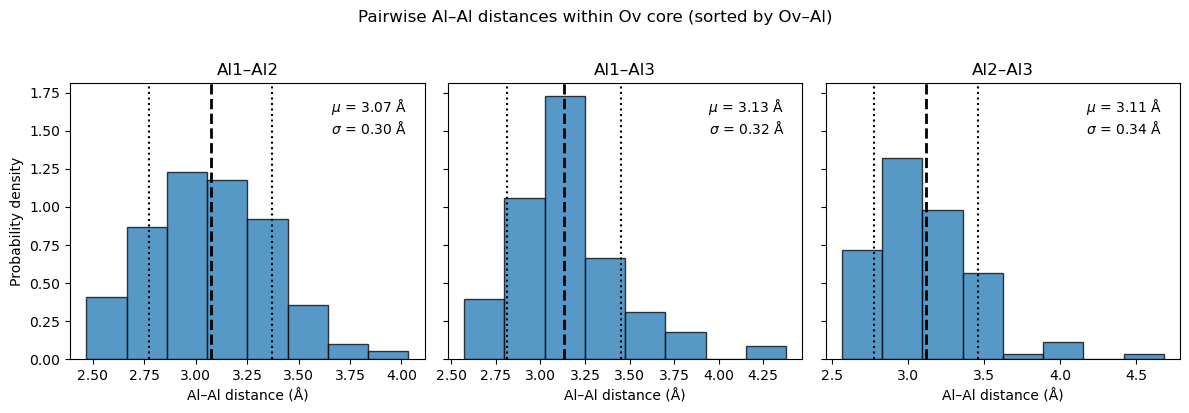

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# Settings
# ==================================================
SUMMARY_CSV = "OvOi_event_summary.csv"
TYPE_OV_AL = 4
NBINS = 8

# ==================================================
# Utilities
# ==================================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)


def read_lammps_atoms(filename):
    with open(filename) as f:
        lines = f.readlines()

    # ---- box ----
    def find_bounds(axis):
        for l in lines:
            if f"{axis}lo {axis}hi" in l:
                lo, hi = map(float, l.split()[:2])
                return lo, hi
        raise RuntimeError("Box not found")

    xlo, xhi = find_bounds("x")
    ylo, yhi = find_bounds("y")
    zlo, zhi = find_bounds("z")
    box = np.array([xhi - xlo, yhi - ylo, zhi - zlo])

    # ---- find atoms (after Masses) ----
    masses_idx = None
    for i, l in enumerate(lines):
        if l.strip().startswith("Masses"):
            masses_idx = i
            break

    start = None
    for i in range(masses_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) >= 7:
            try:
                int(parts[0])
                int(parts[2])
                start = i
                break
            except ValueError:
                continue

    pos, types = [], []
    for i in range(start, len(lines)):
        s = lines[i].strip()
        if not s:
            break
        parts = s.split()
        if len(parts) < 7:
            break
        try:
            int(parts[0])
            int(parts[2])
        except ValueError:
            break

        types.append(int(parts[2]))
        pos.append([float(parts[4]), float(parts[5]), float(parts[6])])

    return np.array(pos), np.array(types), box


# ==================================================
# Collect Al–Al distances (sorted by Ov)
# ==================================================
df = pd.read_csv(SUMMARY_CSV)

pair_dists = {
    "Al1–Al2": [],
    "Al1–Al3": [],
    "Al2–Al3": []
}

for _, row in df.iterrows():
    eid = int(row["event_id"])
    datafile = f"event_{eid:03d}_OvOi.data"

    pos, types, box = read_lammps_atoms(datafile)
    Ov = np.array([row["Ov_x"], row["Ov_y"], row["Ov_z"]])

    core_idx = np.where(types == TYPE_OV_AL)[0]
    if len(core_idx) != 3:
        continue

    core_pos = pos[core_idx]

    # —— 关键：按 Ov–Al 距离排序
    disp = minimum_image(core_pos - Ov, box)
    d_ov = np.linalg.norm(disp, axis=1)
    order = np.argsort(d_ov)
    core_pos = core_pos[order]

    d12 = np.linalg.norm(minimum_image(core_pos[0] - core_pos[1], box))
    d13 = np.linalg.norm(minimum_image(core_pos[0] - core_pos[2], box))
    d23 = np.linalg.norm(minimum_image(core_pos[1] - core_pos[2], box))

    pair_dists["Al1–Al2"].append(d12)
    pair_dists["Al1–Al3"].append(d13)
    pair_dists["Al2–Al3"].append(d23)


# ==================================================
# Plot: histograms (group-meeting style)
# ==================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, key in zip(axes, pair_dists.keys()):
    data = np.array(pair_dists[key])
    mu = data.mean()
    sigma = data.std()

    ax.hist(
        data,
        bins=NBINS,
        density=True,
        alpha=0.75,
        edgecolor="black"
    )

    ax.axvline(mu, color="black", linestyle="--", linewidth=2)
    ax.axvline(mu - sigma, color="black", linestyle=":", linewidth=1.5)
    ax.axvline(mu + sigma, color="black", linestyle=":", linewidth=1.5)

    ax.set_title(key)
    ax.set_xlabel("Al–Al distance (Å)")

    ax.text(
        0.95, 0.95,
        f"$\\mu$ = {mu:.2f} Å\n$\\sigma$ = {sigma:.2f} Å",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10
    )

axes[0].set_ylabel("Probability density")
fig.suptitle("Pairwise Al–Al distances within Ov core (sorted by Ov–Al)", y=1.02)
fig.tight_layout()
plt.show()



=== Ov first-shell Al CN summary (Al–O, r_c = 2.3303 Å) ===
Ov first-shell Al: <CN> = 3.443 ± 0.036
Bulk Al          : <CN> = 4.408 ± 0.008 (reference)


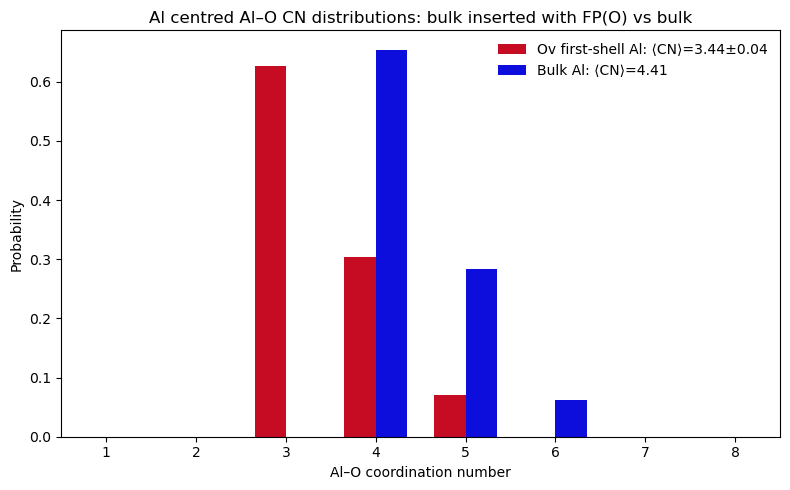

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Settings
# ===============================
SUMMARY_CSV = "OvOi_event_summary.csv"
RC_ALO = 2.3303  # Å

TYPE_AL = 1
TYPE_O  = 2
TYPE_OI = 3
TYPE_CORE_AL = 4

TYPE_OXYGEN = [TYPE_O, TYPE_OI]
TYPE_ALL_AL = [TYPE_AL, TYPE_CORE_AL]

# Bulk reference
bulk_prob = {4: 0.654318, 5: 0.283481, 6: 0.062199}
BULK_MEAN = 4.4079
BULK_SE   = 0.0084

CN_MAX = 9

# ===============================
# Utilities
# ===============================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)

# ------------------------------------------------
# Robust reader (Masses-based, 已验证可用)
# ------------------------------------------------
def read_lammps_atoms(filename):
    with open(filename) as f:
        lines = f.readlines()

    # ---- box ----
    def find_bounds(axis):
        for l in lines:
            if f"{axis}lo {axis}hi" in l:
                lo, hi = map(float, l.split()[:2])
                return lo, hi
        raise RuntimeError(f"Box bounds not found for {axis}")

    xlo, xhi = find_bounds("x")
    ylo, yhi = find_bounds("y")
    zlo, zhi = find_bounds("z")
    box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], float)

    # ---- find Masses ----
    masses_idx = None
    for i, l in enumerate(lines):
        if l.strip().startswith("Masses"):
            masses_idx = i
            break
    if masses_idx is None:
        raise RuntimeError("Masses section not found")

    # ---- find first atom line after Masses ----
    start = None
    for i in range(masses_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) >= 7:
            try:
                int(parts[0]); int(parts[2])
                float(parts[4]); float(parts[5]); float(parts[6])
                start = i
                break
            except ValueError:
                continue

    if start is None:
        raise RuntimeError("No atom data found")

    # ---- read atoms ----
    pos, types = [], []
    for i in range(start, len(lines)):
        s = lines[i].strip()
        if not s:
            break
        parts = s.split()
        if len(parts) < 7:
            break
        try:
            int(parts[0]); int(parts[2])
        except ValueError:
            break

        types.append(int(parts[2]))
        pos.append([float(parts[4]), float(parts[5]), float(parts[6])])

    return np.array(pos, float), np.array(types, int), box

# ===============================
# Main CN analysis
# ===============================
df = pd.read_csv(SUMMARY_CSV)

# 🔥 核心：所有 Ov first-shell Al 的 CN 放在一个池子里
CN_core_all = []

for _, row in df.iterrows():
    eid = int(row["event_id"])
    datafile = f"event_{eid:03d}_OvOi.data"
    if not os.path.exists(datafile):
        raise FileNotFoundError(f"[event {eid}] Missing {datafile}")

    pos, types, box = read_lammps_atoms(datafile)
    Ov = np.array([row["Ov_x"], row["Ov_y"], row["Ov_z"]], float)

    # ---- basic sanity ----
    if np.sum(types == TYPE_CORE_AL) != 3:
        raise RuntimeError(f"[event {eid:03d}] core Al count != 3")
    if np.sum(types == TYPE_OI) != 1:
        raise RuntimeError(f"[event {eid:03d}] Oi count != 1")

    # ---- core Al positions ----
    core_idx = np.where(types == TYPE_CORE_AL)[0]
    core_pos = pos[core_idx]

    # ---- oxygen positions ----
    O_idx = np.where(np.isin(types, TYPE_OXYGEN))[0]
    O_pos = pos[O_idx]

    # ---- CN calculation (each Al is an equivalent first-shell sample) ----
    for p in core_pos:
        disp = minimum_image(O_pos - p, box)
        CN = int(np.sum(np.linalg.norm(disp, axis=1) < RC_ALO))
        CN_core_all.append(CN)

# ===============================
# Summary
# ===============================
def mean_se(arr):
    arr = np.asarray(arr, float)
    return arr.mean(), arr.std(ddof=1) / np.sqrt(len(arr))

m_core, se_core = mean_se(CN_core_all)

print("\n=== Ov first-shell Al CN summary (Al–O, r_c = 2.3303 Å) ===")
print(f"Ov first-shell Al: <CN> = {m_core:.3f} ± {se_core:.3f}")
print(f"Bulk Al          : <CN> = {BULK_MEAN:.3f} ± {BULK_SE:.3f} (reference)")

# ===============================
# Plot: Ov first-shell vs bulk
# ===============================
cn_values = np.arange(1, CN_MAX)

def cn_prob(arr):
    arr = np.asarray(arr, int)
    return np.array([np.mean(arr == c) for c in cn_values])

p_core = cn_prob(CN_core_all)

# bulk probability array
pb = np.zeros_like(cn_values, float)
for cn, p in bulk_prob.items():
    if cn in cn_values:
        pb[cn_values == cn] = p

# ---- plot ----
width = 0.35
x = cn_values

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2, p_core, width,
    label=f"Ov first-shell Al: ⟨CN⟩={m_core:.2f}±{se_core:.2f}",
    color="#C50C22"
)

plt.bar(
    x + width/2, pb, width,
    label=f"Bulk Al: ⟨CN⟩={BULK_MEAN:.2f}",
    color="#0D0DDC"
)

plt.xlabel("Al–O coordination number")
plt.ylabel("Probability")
plt.title("Al centred Al–O CN distributions: bulk inserted with FP(O) vs bulk")

plt.xticks(cn_values)
plt.xlim(0.5, CN_MAX - 0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


[OK] Analysed 100 events × 3 core Al


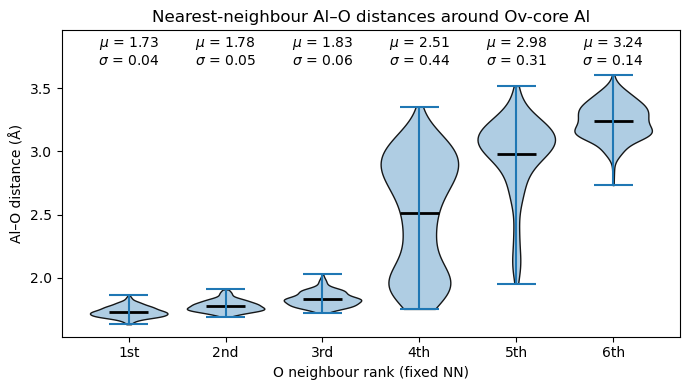

In [6]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Settings
# =====================================
DATA_PATTERN = "event_*_OvOi.data"

TYPE_CORE_AL = 4
TYPE_OXYGEN  = [2, 3]   # O + Oi

N_NN = 6   # number of nearest O neighbours

# =====================================
# Utilities
# =====================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)


def read_lammps_atoms(filename):
    with open(filename) as f:
        lines = f.readlines()

    # ---- box ----
    def find_bounds(axis):
        for l in lines:
            if f"{axis}lo {axis}hi" in l:
                lo, hi = map(float, l.split()[:2])
                return lo, hi
        raise RuntimeError(f"[{filename}] box bounds not found")

    xlo, xhi = find_bounds("x")
    ylo, yhi = find_bounds("y")
    zlo, zhi = find_bounds("z")
    box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], float)

    # ---- find Masses ----
    masses_idx = None
    for i, l in enumerate(lines):
        if l.strip().startswith("Masses"):
            masses_idx = i
            break
    if masses_idx is None:
        raise RuntimeError("Masses section not found")

    # ---- find first atom line ----
    start = None
    for i in range(masses_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) >= 7:
            try:
                int(parts[0]); int(parts[2])
                float(parts[4]); float(parts[5]); float(parts[6])
                start = i
                break
            except ValueError:
                continue
    if start is None:
        raise RuntimeError("Atom block not found")

    pos, types = [], []
    for i in range(start, len(lines)):
        s = lines[i].strip()
        if not s:
            break
        parts = s.split()
        if len(parts) < 7:
            break
        try:
            int(parts[0]); int(parts[2])
        except ValueError:
            break

        types.append(int(parts[2]))
        pos.append([float(parts[4]), float(parts[5]), float(parts[6])])

    return np.asarray(pos), np.asarray(types), box


# =====================================
# NN analysis: type4 Al → 6 nearest O
# =====================================
files = sorted(glob.glob(DATA_PATTERN))
if len(files) == 0:
    raise RuntimeError("No OvOi event data files found")

# NN distances grouped by rank
nn_dist = {r: [] for r in range(1, N_NN + 1)}

for fname in files:
    pos, types, box = read_lammps_atoms(fname)

    core_idx = np.where(types == TYPE_CORE_AL)[0]
    if len(core_idx) != 3:
        raise RuntimeError(f"[{fname}] core Al count = {len(core_idx)}")

    O_idx = np.where(np.isin(types, TYPE_OXYGEN))[0]

    core_pos = pos[core_idx]
    O_pos    = pos[O_idx]

    for p in core_pos:
        disp = minimum_image(O_pos - p, box)
        d = np.linalg.norm(disp, axis=1)

        order = np.argsort(d)[:N_NN]
        for r, idx in enumerate(order, start=1):
            nn_dist[r].append(d[idx])

print(f"[OK] Analysed {len(files)} events × 3 core Al")


# =====================================
# Plot: NN distance violin (with μ, σ)
# =====================================
plt.figure(figsize=(7, 4))

data = [nn_dist[r] for r in range(1, N_NN + 1)]

parts = plt.violinplot(
    data,
    showmeans=True,
    showextrema=True,
    widths=0.8
)

# ---- style ----
for pc in parts["bodies"]:
    pc.set_facecolor("#A6C8E0")
    pc.set_edgecolor("black")
    pc.set_alpha(0.9)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linewidth(2)

plt.xticks(
    range(1, N_NN + 1),
    ["1st", "2nd", "3rd", "4th", "5th", "6th"]
)

plt.xlabel("O neighbour rank (fixed NN)")
plt.ylabel("Al–O distance (Å)")
plt.title("Nearest-neighbour Al–O distances around Ov-core Al")

# ---- annotate mean & std on each violin ----
ymax = max(max(arr) for arr in data)

for i, arr in enumerate(data, start=1):
    arr = np.asarray(arr)
    mu = arr.mean()
    sigma = arr.std(ddof=1)

    plt.text(
        i,
        ymax + 0.05,
        f"$\\mu$ = {mu:.2f}\n$\\sigma$ = {sigma:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(top=ymax + 0.35)
plt.tight_layout()
plt.show()

=== Oi-centered O–Al CN ===
CN= 0  prob=0.010000
CN= 1  prob=0.260000
CN= 2  prob=0.500000
CN= 3  prob=0.220000
CN= 4  prob=0.010000
CN= 5  prob=0.000000
<CN>_Oi = 1.9600 ± 0.0751


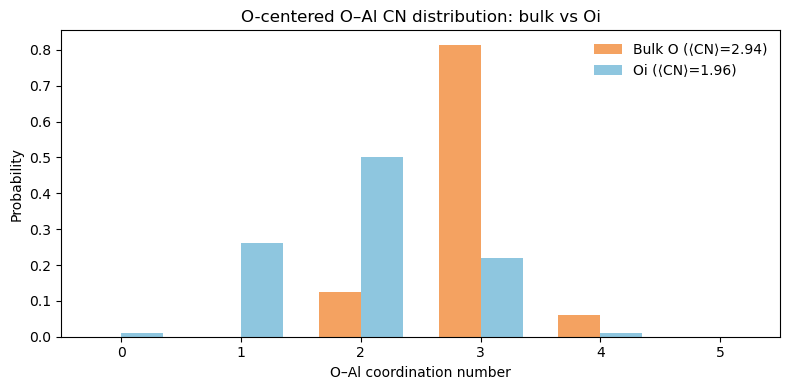

In [7]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Settings
# ===============================
EVENT_PATTERN = "event_*_OvOi.data"

TYPE_AL = 1
TYPE_OI = 3

r_cut_AO = 2.3303   # Å
CN_MAX = 5

# ===============================
# Utilities
# ===============================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)


def read_lammps_atoms(filename):
    with open(filename) as f:
        lines = f.readlines()

    # ---- box ----
    def find_bounds(axis):
        for l in lines:
            if f"{axis}lo {axis}hi" in l:
                lo, hi = map(float, l.split()[:2])
                return lo, hi
        raise RuntimeError("Box bounds not found")

    xlo, xhi = find_bounds("x")
    ylo, yhi = find_bounds("y")
    zlo, zhi = find_bounds("z")
    box = np.array([xhi - xlo, yhi - ylo, zhi - zlo])

    # ---- Masses-based atom read ----
    masses_idx = None
    for i, l in enumerate(lines):
        if l.strip().startswith("Masses"):
            masses_idx = i
            break

    start = None
    for i in range(masses_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) >= 7:
            try:
                int(parts[0]); int(parts[2])
                float(parts[4])
                start = i
                break
            except ValueError:
                continue

    pos, types = [], []
    for i in range(start, len(lines)):
        s = lines[i].strip()
        if not s:
            break
        parts = s.split()
        if len(parts) < 7:
            break
        try:
            int(parts[0]); int(parts[2])
        except ValueError:
            break

        types.append(int(parts[2]))
        pos.append([float(parts[4]), float(parts[5]), float(parts[6])])

    return np.asarray(pos), np.asarray(types), box


# ===============================
# Oi-centered O–Al CN
# ===============================
cn_oi = []

files = sorted(glob.glob(EVENT_PATTERN))
if not files:
    raise RuntimeError("No OvOi event files found")

for f in files:
    pos, types, box = read_lammps_atoms(f)

    oi_idx = np.where(types == TYPE_OI)[0]
    if len(oi_idx) != 1:
        raise RuntimeError(f"[{f}] Oi count = {len(oi_idx)}")

    al_idx = np.where(types == TYPE_AL)[0]

    Oi_pos = pos[oi_idx][0]
    Al_pos = pos[al_idx]

    disp = minimum_image(Al_pos - Oi_pos, box)
    d = np.linalg.norm(disp, axis=1)

    cn = np.sum(d < r_cut_AO)
    cn_oi.append(cn)

cn_oi = np.asarray(cn_oi)

# CN probability
cn_vals = np.arange(CN_MAX + 1)
p_oi = np.array([np.mean(cn_oi == c) for c in cn_vals])

oi_mean = cn_oi.mean()
oi_se   = cn_oi.std(ddof=1) / np.sqrt(len(cn_oi))

print("=== Oi-centered O–Al CN ===")
for c, p in zip(cn_vals, p_oi):
    print(f"CN={c:2d}  prob={p:.6f}")
print(f"<CN>_Oi = {oi_mean:.4f} ± {oi_se:.4f}")

# ===============================
# Bulk O-centered reference (given)
# ===============================
bulk_cn_prob = {
    0: 0.0,
    1: 0.000001,
    2: 0.124055,
    3: 0.813779,
    4: 0.061690,
    5: 0.000476,
}

bulk_cn_mean = 2.9386
bulk_cn_se   = 0.0056

p_bulk = np.array([bulk_cn_prob.get(c, 0.0) for c in cn_vals])

# ===============================
# Plot
# ===============================
width = 0.35
x = cn_vals

plt.figure(figsize=(8, 4))

plt.bar(
    x - width/2, p_bulk, width,
    label=f"Bulk O (⟨CN⟩={bulk_cn_mean:.2f})",
    color="#F4A261"
)

plt.bar(
    x + width/2, p_oi, width,
    label=f"Oi (⟨CN⟩={oi_mean:.2f})",
    color="#8EC6DF"
)

plt.xlabel("O–Al coordination number")
plt.ylabel("Probability")
plt.title("O-centered O–Al CN distribution: bulk vs Oi")

plt.xticks(cn_vals)
plt.xlim(-0.5, CN_MAX + 0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

=== Oi localised O-centered Al–O CN ===
CN= 0  prob=0.010000
CN= 1  prob=0.260000
CN= 2  prob=0.500000
CN= 3  prob=0.220000
CN= 4  prob=0.010000
CN= 5  prob=0.000000
<CN>_Oi = 1.9600 ± 0.0751

=== Ov-core Al localised Al-centered Al–O CN ===
CN= 1  prob=0.000000
CN= 2  prob=0.000000
CN= 3  prob=0.626667
CN= 4  prob=0.303333
CN= 5  prob=0.070000
CN= 6  prob=0.000000
CN= 7  prob=0.000000
CN= 8  prob=0.000000
CN= 9  prob=0.000000
<CN>_Ov-core Al = 3.4433 ± 0.0360



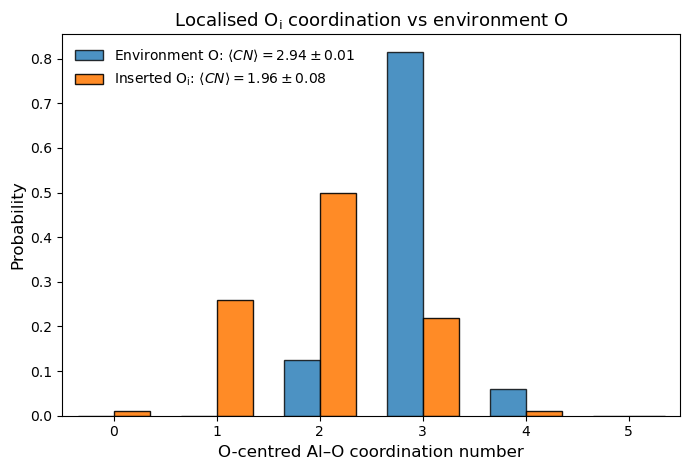

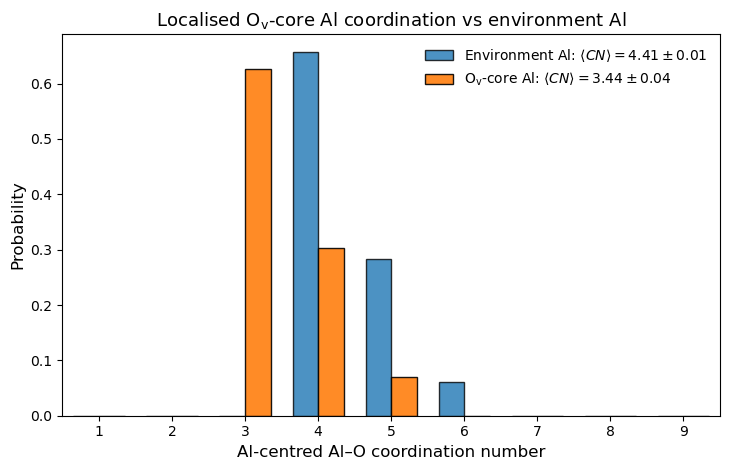

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# Settings
# ============================================================
EVENT_PATTERN = "event_*_OvOi.data"
SUMMARY_CSV   = "OvOi_event_summary.csv"

RC_ALO = 2.3303   # Å, Al-O CN cutoff

TYPE_AL      = 1
TYPE_O       = 2
TYPE_OI      = 3
TYPE_CORE_AL = 4

TYPE_OXYGEN = [TYPE_O, TYPE_OI]
TYPE_ALL_AL = [TYPE_AL, TYPE_CORE_AL]

# ============================================================
# Bulk reference distributions (already determined from your reference ensemble)
# ============================================================
# O-centered Al-O CN (environment O counts nearby Al)
bulk_O_prob = {
    0: 0.0,
    1: 0.000001,
    2: 0.124910,
    3: 0.813876,
    4: 0.060757,
    5: 0.000456,
}
bulk_O_mean = 2.9368
bulk_O_se   = 0.0056

# Al-centered Al-O CN (environment Al counts nearby O)
bulk_Al_prob = {
    0: 0.0,
    1: 0.0,
    2: 0.0,
    3: 0.000001,
    4: 0.656185,
    5: 0.282490,
    6: 0.061323,
    7: 0.0,
    8: 0.0,
    9: 0.0,
}
bulk_Al_mean = 4.4051
bulk_Al_se   = 0.0084

# plotting range
CN_MAX_O  = 5   # for O-centered CN
CN_MAX_AL = 9   # for Al-centered CN

# ============================================================
# Utilities
# ============================================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)

def read_lammps_atoms(filename):
    """
    Robust reader for your LAMMPS data files
    (Masses-based parser, same logic as your validated version)
    """
    with open(filename) as f:
        lines = f.readlines()

    # ---- box ----
    def find_bounds(axis):
        for l in lines:
            if f"{axis}lo {axis}hi" in l:
                lo, hi = map(float, l.split()[:2])
                return lo, hi
        raise RuntimeError(f"Box bounds not found for {axis}")

    xlo, xhi = find_bounds("x")
    ylo, yhi = find_bounds("y")
    zlo, zhi = find_bounds("z")
    box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

    # ---- find Masses ----
    masses_idx = None
    for i, l in enumerate(lines):
        if l.strip().startswith("Masses"):
            masses_idx = i
            break
    if masses_idx is None:
        raise RuntimeError(f"[{filename}] Masses section not found")

    # ---- find first atom line after Masses ----
    start = None
    for i in range(masses_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) >= 7:
            try:
                int(parts[0]); int(parts[2])
                float(parts[4]); float(parts[5]); float(parts[6])
                start = i
                break
            except ValueError:
                continue
    if start is None:
        raise RuntimeError(f"[{filename}] No atom data found")

    # ---- read atoms ----
    pos, types = [], []
    for i in range(start, len(lines)):
        s = lines[i].strip()
        if not s:
            break
        parts = s.split()
        if len(parts) < 7:
            break
        try:
            int(parts[0]); int(parts[2])
        except ValueError:
            break

        types.append(int(parts[2]))
        pos.append([float(parts[4]), float(parts[5]), float(parts[6])])

    return np.asarray(pos, float), np.asarray(types, int), box

def mean_se(arr):
    arr = np.asarray(arr, dtype=float)
    return arr.mean(), arr.std(ddof=1) / np.sqrt(len(arr))

# ============================================================
# Load all event files
# ============================================================
files = sorted(glob.glob(EVENT_PATTERN))
if not files:
    raise RuntimeError("No OvOi event files found")

# If you use Ov coordinates from summary CSV for other analyses, keep this
if not os.path.exists(SUMMARY_CSV):
    raise FileNotFoundError(f"Missing {SUMMARY_CSV}")
summary_df = pd.read_csv(SUMMARY_CSV)

# ============================================================
# 1) Oi localised CN distribution
#    Oi counts nearby Al (including core Al, if present)
# ============================================================
cn_oi = []

for f in files:
    pos, types, box = read_lammps_atoms(f)

    oi_idx = np.where(types == TYPE_OI)[0]
    if len(oi_idx) != 1:
        raise RuntimeError(f"[{f}] Oi count = {len(oi_idx)} (expected 1)")

    al_idx = np.where(np.isin(types, TYPE_ALL_AL))[0]

    oi_pos = pos[oi_idx[0]]
    al_pos = pos[al_idx]

    disp = minimum_image(al_pos - oi_pos, box)
    d = np.linalg.norm(disp, axis=1)

    cn = int(np.sum(d < RC_ALO))
    cn_oi.append(cn)

cn_oi = np.asarray(cn_oi, dtype=int)

cn_vals_O = np.arange(0, CN_MAX_O + 1)
p_oi = np.array([np.mean(cn_oi == c) for c in cn_vals_O], dtype=float)

p_bulk_O = np.array([bulk_O_prob.get(c, 0.0) for c in cn_vals_O], dtype=float)

oi_mean, oi_se = mean_se(cn_oi)

print("=== Oi localised O-centered Al–O CN ===")
for c, p in zip(cn_vals_O, p_oi):
    print(f"CN={c:2d}  prob={p:.6f}")
print(f"<CN>_Oi = {oi_mean:.4f} ± {oi_se:.4f}")
print()

# ============================================================
# 2) Ov-core Al localised CN distribution
#    each core Al counts nearby O (including Oi if close enough)
# ============================================================
cn_core_al = []

for f in files:
    pos, types, box = read_lammps_atoms(f)

    core_idx = np.where(types == TYPE_CORE_AL)[0]
    if len(core_idx) != 3:
        raise RuntimeError(f"[{f}] Ov-core Al count = {len(core_idx)} (expected 3)")

    oxy_idx = np.where(np.isin(types, TYPE_OXYGEN))[0]

    core_pos = pos[core_idx]
    oxy_pos  = pos[oxy_idx]

    for p in core_pos:
        disp = minimum_image(oxy_pos - p, box)
        d = np.linalg.norm(disp, axis=1)
        cn = int(np.sum(d < RC_ALO))
        cn_core_al.append(cn)

cn_core_al = np.asarray(cn_core_al, dtype=int)

cn_vals_Al = np.arange(1, CN_MAX_AL + 1)
p_core_al = np.array([np.mean(cn_core_al == c) for c in cn_vals_Al], dtype=float)

p_bulk_Al = np.array([bulk_Al_prob.get(c, 0.0) for c in cn_vals_Al], dtype=float)

core_mean, core_se = mean_se(cn_core_al)

print("=== Ov-core Al localised Al-centered Al–O CN ===")
for c, p in zip(cn_vals_Al, p_core_al):
    print(f"CN={c:2d}  prob={p:.6f}")
print(f"<CN>_Ov-core Al = {core_mean:.4f} ± {core_se:.4f}")
print()

# ============================================================
# Plot 1: Oi localised vs environment O
# ============================================================
plt.figure(figsize=(7.0, 4.8))

width = 0.35
x = cn_vals_O

plt.bar(
    x - width/2, p_bulk_O, width=width,
    edgecolor="k", alpha=0.80,
    label=rf"Environment O: $\langle CN \rangle = {bulk_O_mean:.2f} \pm {bulk_O_se:.2f}$"
)

plt.bar(
    x + width/2, p_oi, width=width,
    edgecolor="k", alpha=0.90,
    label=rf"Inserted O$_\mathrm{{i}}$: $\langle CN \rangle = {oi_mean:.2f} \pm {oi_se:.2f}$"
)

plt.xlabel("O-centred Al–O coordination number", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Localised O$_\\mathrm{i}$ coordination vs environment O", fontsize=13)
plt.xticks(cn_vals_O)
plt.xlim(-0.5, CN_MAX_O + 0.5)
plt.ylim(bottom=0)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("Oi_localised_vs_environment_CN.png", dpi=300)
plt.show()

# ============================================================
# Plot 2: Ov-core Al localised vs bulk Al
# ============================================================
plt.figure(figsize=(7.4, 4.8))

width = 0.35
x = cn_vals_Al

plt.bar(
    x - width/2, p_bulk_Al, width=width,
    edgecolor="k", alpha=0.80,
    label=rf"Environment Al: $\langle CN \rangle = {bulk_Al_mean:.2f} \pm {bulk_Al_se:.2f}$"
)

plt.bar(
    x + width/2, p_core_al, width=width,
    edgecolor="k", alpha=0.90,
    label=rf"O$_\mathrm{{v}}$-core Al: $\langle CN \rangle = {core_mean:.2f} \pm {core_se:.2f}$"
)

plt.xlabel("Al-centred Al–O coordination number", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Localised O$_\\mathrm{v}$-core Al coordination vs environment Al", fontsize=13)
plt.xticks(cn_vals_Al)
plt.xlim(0.5, CN_MAX_AL + 0.5)
plt.ylim(bottom=0)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("Ovcore_localised_vs_environment_CN.png", dpi=300)
plt.show()

In [3]:
import numpy as np
from glob import glob

# ===================== USER SETTINGS =====================
PATTERN = "event_*_OvOi.data"
TYPE_OV_AL = 4
# ========================================================


def read_box_and_type4(path):
    """
    Read orthorhombic box (lo/hi) and wrapped positions of type4 atoms from a LAMMPS data file.
    Returns:
        lo   (3,)
        box  (3,)  # lengths
        xyz4 (3,3) # wrapped positions (shifted into [0,L))
    """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # ---- box bounds ----
    xlo = xhi = ylo = yhi = zlo = zhi = None
    for line in lines:
        if "xlo xhi" in line:
            xlo, xhi = map(float, line.split()[:2])
        elif "ylo yhi" in line:
            ylo, yhi = map(float, line.split()[:2])
        elif "zlo zhi" in line:
            zlo, zhi = map(float, line.split()[:2])

    if None in (xlo, xhi, ylo, yhi, zlo, zhi):
        raise RuntimeError(f"{path}: failed to parse box bounds.")

    lo = np.array([xlo, ylo, zlo], dtype=float)
    box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

    # ---- find Atoms section ----
    start = None
    for i, line in enumerate(lines):
        if line.strip().startswith("Atoms"):
            start = i + 2
            break
    if start is None:
        raise RuntimeError(f"{path}: No Atoms section found.")

    xyz4 = []
    for line in lines[start:]:
        if not line.strip():
            break
        parts = line.split()
        atype = int(parts[2])
        if atype != TYPE_OV_AL:
            continue

        x, y, z = map(float, parts[4:7])
        r = np.array([x, y, z], dtype=float)

        # shift to [0, L) so MIC works consistently
        r = (r - lo) % box
        xyz4.append(r)

    xyz4 = np.array(xyz4, dtype=float)
    if xyz4.shape[0] != 3:
        raise RuntimeError(f"{path}: expected 3 type4 atoms, got {xyz4.shape[0]}")

    return lo, box, xyz4


def mic_delta(dr, box):
    """
    Minimum-image delta for orthorhombic PBC.
    """
    return dr - box * np.rint(dr / box)


def mic_distance(a, b, box):
    """
    Minimum-image distance between two points under PBC.
    """
    dr = b - a
    dr = mic_delta(dr, box)
    return float(np.sqrt(np.dot(dr, dr)))


def triangle_metrics_mic(xyz3, box):
    """
    Compute 3 edges using MIC; return:
      d_bar: mean edge length
      chi  : relative RMS distortion
      dists: (3,) edges [d12, d23, d31]
    """
    d12 = mic_distance(xyz3[0], xyz3[1], box)
    d23 = mic_distance(xyz3[1], xyz3[2], box)
    d31 = mic_distance(xyz3[2], xyz3[0], box)
    dists = np.array([d12, d23, d31], dtype=float)

    d_bar = dists.mean()
    chi = np.sqrt(np.mean((dists - d_bar) ** 2)) / d_bar
    return d_bar, chi, dists


def main():
    files = sorted(glob(PATTERN))
    if not files:
        raise RuntimeError(f"No files matched: {PATTERN}")

    d_all = []
    chi_all = []

    # debug: print first file edges to sanity check (~3 Å you expect)
    first_debug_printed = False

    for f in files:
        lo, box, xyz4 = read_box_and_type4(f)
        d_bar, chi, dists = triangle_metrics_mic(xyz4, box)

        if not first_debug_printed:
            print("---- DEBUG (first file) ----")
            print(f"file: {f}")
            print(f"box: {box}")
            print("type4 wrapped positions in [0,L):")
            print(xyz4)
            print(f"MIC edges (Å): d12={dists[0]:.4f}, d23={dists[1]:.4f}, d31={dists[2]:.4f}")
            print(f"d_bar={d_bar:.4f}, chi={chi:.4f}")
            print("----------------------------\n")
            first_debug_printed = True

        d_all.append(d_bar)
        chi_all.append(chi)

    d_all = np.array(d_all, dtype=float)
    chi_all = np.array(chi_all, dtype=float)

    print("====================================")
    print(" Ov-core Al3 triangle (MD BEFORE)")
    print(" (PBC minimum-image geometry)")
    print("====================================")
    print(f"Events used : {len(d_all)}\n")

    print(f"<d>   = {d_all.mean():.4f} Å")
    print(f"std d = {d_all.std(ddof=0):.4f} Å\n")

    print(f"<χ>   = {chi_all.mean():.4f}")
    print(f"std χ = {chi_all.std(ddof=0):.4f}\n")

    print("Interpretation:")
    print(" χ < 0.10  → near-equilateral")
    print(" χ ~ 0.2   → distorted triangle")
    print(" χ > 0.3   → no triangular motif")


if __name__ == "__main__":
    main()



---- DEBUG (first file) ----
file: event_001_OvOi.data
box: [21.75489863 21.75489863 21.75489863]
type4 wrapped positions in [0,L):
[[4.88450221 3.33135728 6.17762592]
 [3.57926957 1.13741847 4.46503396]
 [3.85632512 0.75393624 7.49024855]]
MIC edges (Å): d12=3.0741, d23=3.0620, d31=3.0697
d_bar=3.0686, chi=0.0016
----------------------------

 Ov-core Al3 triangle (MD BEFORE)
 (PBC minimum-image geometry)
Events used : 100

<d>   = 3.1064 Å
std d = 0.1578 Å

<χ>   = 0.0766
std χ = 0.0427

Interpretation:
 χ < 0.10  → near-equilateral
 χ ~ 0.2   → distorted triangle
 χ > 0.3   → no triangular motif


=== Initial Ov vacancy volume analysis ===
event 001: V_vac(0) = 0.3560 Å^3,  R_vac(0) = 0.4397 Å,  valid grid points = 31514
event 002: V_vac(0) = 0.2340 Å^3,  R_vac(0) = 0.3823 Å,  valid grid points = 28360
event 003: V_vac(0) = 0.4200 Å^3,  R_vac(0) = 0.4646 Å,  valid grid points = 30706
event 004: V_vac(0) = 0.3646 Å^3,  R_vac(0) = 0.4432 Å,  valid grid points = 31556
event 005: V_vac(0) = 0.2095 Å^3,  R_vac(0) = 0.3684 Å,  valid grid points = 28695
event 006: V_vac(0) = 0.3630 Å^3,  R_vac(0) = 0.4425 Å,  valid grid points = 30863
event 007: V_vac(0) = 0.3378 Å^3,  R_vac(0) = 0.4321 Å,  valid grid points = 31291
event 008: V_vac(0) = 0.2850 Å^3,  R_vac(0) = 0.4082 Å,  valid grid points = 30682
event 009: V_vac(0) = 0.4079 Å^3,  R_vac(0) = 0.4601 Å,  valid grid points = 30720
event 010: V_vac(0) = 0.3185 Å^3,  R_vac(0) = 0.4237 Å,  valid grid points = 31115
event 011: V_vac(0) = 0.7026 Å^3,  R_vac(0) = 0.5515 Å,  valid grid points = 29020
event 012: V_vac(0) = 0.4063 Å^3,  R_vac(0) 

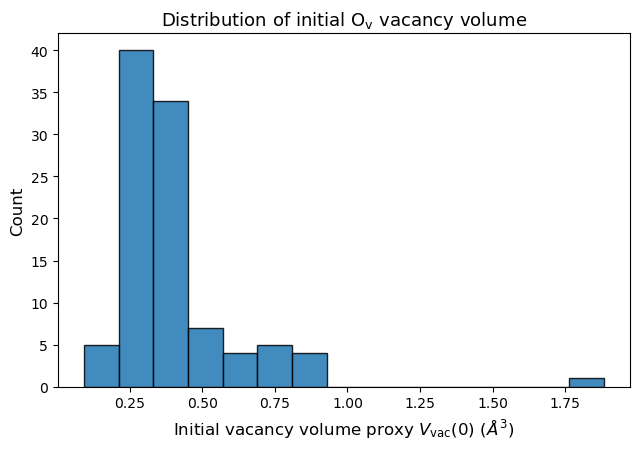

In [3]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================
EVENT_PATTERN = "event_*_OvOi.data"

TYPE_AL      = 1
TYPE_O       = 2
TYPE_OI      = 3
TYPE_CORE_AL = 4

# ---------- ballooning settings ----------
ROI_RADIUS   = 1.0   # Å
GRID_SPACING = 0.05  # Å

# !!! Fill these with your own excluded radii definition !!!
# e.g. from the left edge of the first-neighbour peak in Al-Al / O-O RDF
R_EXCL_AL = 1   # <-- replace with your value
R_EXCL_O  = 1  # <-- replace with your value

# ============================================================
# Utilities
# ============================================================
def minimum_image(vec, box):
    return vec - box * np.round(vec / box)

def read_lammps_atoms(filename):
    """
    Robust reader for your LAMMPS data files
    """
    with open(filename) as f:
        lines = f.readlines()

    # ---- box ----
    def find_bounds(axis):
        for l in lines:
            if f"{axis}lo {axis}hi" in l:
                lo, hi = map(float, l.split()[:2])
                return lo, hi
        raise RuntimeError(f"Box bounds not found for {axis}")

    xlo, xhi = find_bounds("x")
    ylo, yhi = find_bounds("y")
    zlo, zhi = find_bounds("z")
    box = np.array([xhi - xlo, yhi - ylo, zhi - zlo], dtype=float)

    # ---- find Masses ----
    masses_idx = None
    for i, l in enumerate(lines):
        if l.strip().startswith("Masses"):
            masses_idx = i
            break
    if masses_idx is None:
        raise RuntimeError(f"[{filename}] Masses section not found")

    # ---- find first atom line after Masses ----
    start = None
    for i in range(masses_idx + 1, len(lines)):
        s = lines[i].strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) >= 7:
            try:
                int(parts[0]); int(parts[2])
                float(parts[4]); float(parts[5]); float(parts[6])
                start = i
                break
            except ValueError:
                continue
    if start is None:
        raise RuntimeError(f"[{filename}] No atom data found")

    # ---- read atoms ----
    pos, types = [], []
    for i in range(start, len(lines)):
        s = lines[i].strip()
        if not s:
            break
        parts = s.split()
        if len(parts) < 7:
            break
        try:
            int(parts[0]); int(parts[2])
        except ValueError:
            break

        types.append(int(parts[2]))
        pos.append([float(parts[4]), float(parts[5]), float(parts[6])])

    return np.asarray(pos, float), np.asarray(types, int), box

def make_roi_grid(center, roi_radius, spacing):
    """
    Generate a cubic grid and keep only points inside the spherical ROI
    """
    offsets = np.arange(-roi_radius, roi_radius + 0.5 * spacing, spacing)
    pts = []
    for dx in offsets:
        for dy in offsets:
            for dz in offsets:
                if dx*dx + dy*dy + dz*dz <= roi_radius*roi_radius:
                    pts.append(center + np.array([dx, dy, dz], dtype=float))
    return np.asarray(pts, dtype=float)

def get_excluded_radii(types):
    """
    Map atom types to excluded radii
    """
    r = np.zeros_like(types, dtype=float)
    r[np.isin(types, [TYPE_AL, TYPE_CORE_AL])] = R_EXCL_AL
    r[np.isin(types, [TYPE_O, TYPE_OI])]       = R_EXCL_O
    return r

def vacancy_volume_for_event(pos, types, box):
    """
    Compute V_vac(0) for one event using the ballooning metric.
    """
    # ---- Ov-core Al set ----
    core_idx = np.where(types == TYPE_CORE_AL)[0]
    if len(core_idx) != 3:
        raise RuntimeError(f"Expected 3 Ov-core Al atoms, got {len(core_idx)}")

    core_pos = pos[core_idx]

    # ---- geometric centroid of Ov-core Al ----
    # unwrap core positions relative to the first core Al before centroid
    ref = core_pos[0]
    core_unwrapped = ref + minimum_image(core_pos - ref, box)
    r_c = core_unwrapped.mean(axis=0)

    # ---- ROI grid ----
    grid_points = make_roi_grid(r_c, ROI_RADIUS, GRID_SPACING)

    # ---- all atoms + excluded radii ----
    atom_radii = get_excluded_radii(types)

    V_list = []
    R_list = []

    for g in grid_points:
        # distances from this grid point to all atoms (minimum image)
        disp = minimum_image(pos - g, box)
        d = np.linalg.norm(disp, axis=1)

        # largest non-overlapping probe radius at this point
        # probe grows until touching the first surrounding atom
        Rk = np.min(d - atom_radii)

        # reject negative or zero cases (inside overlap region)
        if Rk > 0:
            Vk = (4.0 / 3.0) * np.pi * Rk**3
            R_list.append(Rk)
            V_list.append(Vk)

    if len(V_list) == 0:
        raise RuntimeError("No valid probe spheres found inside ROI. Check excluded radii / ROI settings.")

    V_list = np.asarray(V_list, dtype=float)
    R_list = np.asarray(R_list, dtype=float)

    V_vac = np.median(V_list)
    R_vac = np.median(R_list)

    return V_vac, R_vac, r_c, len(V_list)

def mean_se(arr):
    arr = np.asarray(arr, dtype=float)
    return arr.mean(), arr.std(ddof=1) / np.sqrt(len(arr))

# ============================================================
# Main loop
# ============================================================
files = sorted(glob.glob(EVENT_PATTERN))
if not files:
    raise RuntimeError("No event_*_OvOi.data files found")

V_all = []
R_all = []
event_ids = []

print("=== Initial Ov vacancy volume analysis ===")
for f in files:
    pos, types, box = read_lammps_atoms(f)
    V_vac, R_vac, r_c, n_valid = vacancy_volume_for_event(pos, types, box)

    # parse event id from filename if possible
    try:
        eid = int(f.split("_")[1])
    except Exception:
        eid = len(event_ids) + 1

    event_ids.append(eid)
    V_all.append(V_vac)
    R_all.append(R_vac)

    print(f"event {eid:03d}: V_vac(0) = {V_vac:.4f} Å^3,  R_vac(0) = {R_vac:.4f} Å,  valid grid points = {n_valid}")

V_all = np.asarray(V_all, dtype=float)
R_all = np.asarray(R_all, dtype=float)

V_mean, V_se = mean_se(V_all)
R_mean, R_se = mean_se(R_all)

print("\n=== Ensemble summary ===")
print(f"<V_vac(0)> = {V_mean:.4f} ± {V_se:.4f} Å^3")
print(f"<R_vac(0)> = {R_mean:.4f} ± {R_se:.4f} Å")

# ============================================================
# Save per-event results
# ============================================================
out = np.column_stack([event_ids, V_all, R_all])
np.savetxt(
    "Ov_initial_vacancy_volume.csv",
    out,
    delimiter=",",
    header="event_id,V_vac_0_A3,R_vac_0_A",
    comments=""
)

# ============================================================
# Plot distribution
# ============================================================
plt.figure(figsize=(6.5, 4.6))
plt.hist(V_all, bins=15, edgecolor="k", alpha=0.85)
plt.xlabel(r"Initial vacancy volume proxy $V_{\mathrm{vac}}(0)$ ($\AA^3$)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of initial O$_\\mathrm{v}$ vacancy volume", fontsize=13)
plt.tight_layout()
plt.savefig("Ov_initial_vacancy_volume_hist.png", dpi=300)
plt.show()